# Импорты и функции

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.4 MB/s eta 0:00:00


In [3]:
import os
import zipfile
import gdown
from pathlib import Path
import pydicom
from PIL import Image, ImageDraw
from IPython.display import display
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib
from datetime import datetime

In [4]:
def fetch_data():
  """
  Download and unpack RSNA Pneumonia Detection dataset
  (https://www.kaggle.com/competitions/rsna-pneumonia-detection-challenge)
  """
  google_file_id = '1nIW5qgn4MurehHDiulrTMHNQMpsu4SRJ'
  zip_file_name = 'rsna-pneumonia-detection-challenge.zip'

  gdown.download(f'https://drive.google.com/uc?id={google_file_id}', zip_file_name, quiet=False)

  with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

  print("\nDone :)")

In [5]:
def extract_dicom_metadata(
    dir_name='stage_2_train_images',
    fields=["PatientID", "PatientSex", "PatientAge"]
    ):
  """
  Extract and save additional metadata from DICOM files to Pandas DataFrame
  """
  data = []
  current_dir = Path(DATA_DIR) / dir_name
  print('Extracting metadata from DICOM images')
  for filename in tqdm(os.listdir(current_dir)):
    if filename.endswith('dcm'):
      dcm_data = pydicom.dcmread(current_dir / filename)
      record = {}
      for field in fields:
          record[field] = dcm_data[field].value
      data.append(record)

  df = pd.DataFrame(data)
  return df

In [6]:
class ChestXRayDataset(Dataset):
    def __init__(self, labels, dcm_dir, transform=None, draw_bbox=False):
        """
        Args:
            labels (df): df c разметкой
            dcm_dir (string): Директория с DICOM файлами
            transform (callable, optional): Опциональные преобразования
            draw_bbox (bool): Рисовать ли bounding box на изображении
        """
        self.annotations = labels
        self.dcm_dir = dcm_dir
        self.transform = transform
        self.draw_bbox = draw_bbox

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        # Получаем информацию из df
        img_id = self.annotations.iloc[idx, 0]
        target = self.annotations.iloc[idx]['target']  # 0/1/2

        # Загружаем DICOM файл
        dcm_path = os.path.join(self.dcm_dir, f"{img_id}.dcm")
        dicom = pydicom.dcmread(dcm_path)
        img = dicom.pixel_array

        # Конвертируем в PIL Image
        img = Image.fromarray(img).convert('RGB')

        # Если есть разметка bbox и разрешено рисовать
        if self.draw_bbox and target in [1, 2]:
            x = self.annotations.iloc[idx]['x']
            y = self.annotations.iloc[idx]['y']
            width = self.annotations.iloc[idx]['width']
            height = self.annotations.iloc[idx]['height']

            draw = ImageDraw.Draw(img)
            color = "red" if target == 1 else "blue"
            draw.rectangle([(x, y), (x+width, y+height)], outline=color, width=3)

        # Применяем трансформации
        if self.transform:
            img = self.transform(img)

        # Получаем дополнительные метаданные
        age = float(dicom.PatientAge) if 'PatientAge' in dicom else 0.0
        sex = 1 if dicom.PatientSex == 'M' else 0 if 'PatientSex' in dicom else 0.5

        return img, torch.tensor(target, dtype=torch.long), {'age': age, 'sex': sex}


def get_chest_xray_data(labels, dcm_dir, batch_size, val_size=0.2, random_state=42):
    """
    Args:
        csv_path: df с разметкой
        dcm_dir: директория с DICOM файлами
        batch_size: размер батча
        val_size: доля валидационной выборки
        random_state: seed
    """
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Трансформации для данных
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(7),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

    transform_val = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

    # Загрузка данных
    print("Загрузка и обработка данных...")
    full_dataset = ChestXRayDataset(labels, dcm_dir, transform=None)

    # Разделение на train и val
    indices = list(range(len(full_dataset)))
    targets = full_dataset.annotations['target'].values

    train_idx, val_idx = train_test_split(
        indices, test_size=val_size, random_state=random_state,
        stratify=targets
    )


    print("\nСоздание тренировочного набора...")
    train_dataset = ChestXRayDataset(labels, dcm_dir, transform=transform_train)
    train_dataset = torch.utils.data.Subset(train_dataset, train_idx)

    print("\nСоздание валидационного набора...")
    val_dataset = ChestXRayDataset(labels, dcm_dir, transform=transform_val, draw_bbox=True)
    val_dataset = torch.utils.data.Subset(val_dataset, val_idx)

    # Функция для создания DataLoader
    def create_loader(dataset, batch_size, shuffle, desc):
        return DataLoader(
            dataset, batch_size=batch_size, shuffle=shuffle,
            num_workers=4, pin_memory=True,
            worker_init_fn=lambda _: np.random.seed(random_state)
        )

    # Создаем DataLoader'ы
    print("\nПодготовка DataLoader'ов...")
    train_loader = create_loader(train_dataset, batch_size, True, "Training")
    val_loader = create_loader(val_dataset, batch_size, False, "Validation")


    print(f"\nРазмер тренировочного набора: {len(train_idx)}")
    print(f"Размер валидационного набора: {len(val_idx)}")
    print(f"Размер батча: {batch_size}")

    return train_loader, val_loader

In [7]:
def val(model, loader, device, criterion):
    model.eval()
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for batch in train_loader:

          if len(batch) == 2:
              data, target = batch
              metadata = None
          else:
              data, target, metadata = batch

          data, target = data.to(device), target.to(device)
          logits = model(data)
          probs = F.softmax(logits, dim=1)

          all_probs.append(probs.cpu().numpy())
          all_targets.append(target.cpu().numpy())


    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    # Вычисляем ROC AUC
    roc_auc = roc_auc_score(all_targets, all_probs, multi_class='ovr', average='macro')
    loss = criterion(torch.tensor(all_probs), torch.tensor(all_targets)).item()

    return loss, roc_auc

def train_epoch(model, optimizer, train_loader, device, criterion):
    model.train()
    all_targets = []
    all_probs = []
    loss_log = []

    for batch in train_loader:

        if len(batch) == 2:
            data, target = batch
            metadata = None
        else:
            data, target, metadata = batch

        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        probs = F.softmax(logits, dim=1)

        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(target.detach().cpu().numpy())
        loss_log.append(loss.item())

    # Объединяем все батчи
    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)

    # Вычисляем ROC AUC
    roc_auc = roc_auc_score(all_targets, all_probs, multi_class='ovr', average='macro')

    return loss_log, roc_auc

def train(model, optimizer, n_epochs, train_loader, val_loader, device, scheduler=None, criterion):
    train_loss_log = []
    train_roc_auc_log = []
    val_loss_log = []
    val_roc_auc_log = []

    for epoch in range(n_epochs):
        train_loss, train_roc_auc = train_epoch(model, optimizer, train_loader, device, criterion)
        val_loss, val_roc_auc = val(model, val_loader, device, criterion)

        train_loss_log.extend(train_loss)
        train_roc_auc_log.append(train_roc_auc)
        val_loss_log.append(val_loss)
        val_roc_auc_log.append(val_roc_auc)

        print(f"Epoch {epoch + 1}/{n_epochs}")
        print(f"Train Loss: {np.mean(train_loss):.4f} | Train ROC AUC: {train_roc_auc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val ROC AUC: {val_roc_auc:.4f}\n")

        if scheduler is not None:
            scheduler.step(val_loss)

    return train_loss_log, train_roc_auc_log, val_loss_log, val_roc_auc_log

In [ ]:
def prepare_meta_features(models, dataloader, device):
    """Собираем вероятности всех моделей для стекинга"""
    all_probs = []
    all_targets = []

    for m in models:
        m.eval()

    with torch.no_grad():
        for batch in dataloader:

            inputs = batch[0].to(device)
            targets = batch[1].numpy()

            # Собираем предсказания всех моделей
            batch_probs = []
            for m in models:
                outputs = m(inputs)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                batch_probs.append(probs)


            stacked_probs = np.hstack(batch_probs)
            all_probs.append(stacked_probs)
            all_targets.append(targets)

    return np.vstack(all_probs), np.concatenate(all_targets)

In [8]:
def calculate_metrics(model, dataloader, device):
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in dataloader:

            if len(batch) == 2:
                inputs, targets = batch
            else:
                inputs, targets, _ = batch

            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())


    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Вычисляем метрики
    f1 = f1_score(all_targets, all_preds, average='weighted')
    acc = balanced_accuracy_score(all_targets, all_preds)


    try:
        roc_auc = roc_auc_score(all_targets, all_probs, multi_class='ovr')
        gini = 2 * roc_auc - 1
    except ValueError:
        roc_auc = 0.5
        gini = 0.0

    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

    return {
        'f1_weighted': f1,
        'gini': gini,
        'roc_auc': roc_auc,
        'balanced_accuracy': acc,
        'predictions': all_preds,
        'probabilities': all_probs
    }

In [ ]:
def calculate_metrics_meta(meta_model, X, y_true):
    """Вычисление всех метрик для мета-модели"""

    y_pred = meta_model.predict(X)
    y_proba = meta_model.predict_proba(X)

    # 1. ROC AUC (multi-class)
    try:
        roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr')
    except ValueError:
        roc_auc = 0.5

    # 2. Коэффициент Джини
    gini = 2 * roc_auc - 1

    # 3. Weighted F1-score
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    acc = balanced_accuracy_score(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

    return {
        'ROC_AUC': roc_auc,
        'Gini': gini,
        'F1_weighted': f1,
        'Balanced_accuracy': acc,
         }

In [9]:
def plot_metrics(train_loss_log, train_roc_auc_log, val_loss_log, val_roc_auc_log):
    plt.figure(figsize=(12, 5))


    plt.subplot(1, 2, 1)
    plt.plot(train_loss_log, label='Train Loss', alpha=0.7)

    val_steps = np.linspace(0, len(train_loss_log)-1, len(val_loss_log))
    plt.plot(val_steps, val_loss_log, 'o-', label='Val Loss')

    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)


    plt.subplot(1, 2, 2)
    plt.plot(train_roc_auc_log, label='Train ROC-AUC', alpha=0.7)

    val_steps = np.linspace(0, len(train_roc_auc_log)-1, len(val_roc_auc_log))
    plt.plot(val_steps, val_roc_auc_log, 'o-', label='Val ROC-AUC')

    plt.xlabel('Training Steps')
    plt.ylabel('ROC-AUC')
    plt.title('Training and Validation ROC-AUC')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt)**self.gamma * ce_loss

        if self.alpha is not None:
            if isinstance(self.alpha, (list, np.ndarray)):
                alpha = torch.tensor(self.alpha, device=inputs.device)[targets]
            else:
                alpha = self.alpha
            focal_loss = alpha * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Подготовка данных
## Загрузка

In [11]:
DATA_DIR = 'data'

try:
  os.mkdir("mod_data")
  os.mkdir("mod_data/train_usual_format")
  os.mkdir("additionals")
except FileExistsError:
  print("Alredy Exists")

version="v1"

In [12]:
fetch_data()

Downloading...
From (original): https://drive.google.com/uc?id=1nIW5qgn4MurehHDiulrTMHNQMpsu4SRJ
From (redirected): https://drive.google.com/uc?id=1nIW5qgn4MurehHDiulrTMHNQMpsu4SRJ&confirm=t&uuid=1cf863e9-f299-40ca-870b-554ae337320f
To: /content/rsna-pneumonia-detection-challenge.zip
100%|██████████| 3.93G/3.93G [00:51<00:00, 75.7MB/s]



Done :)


In [13]:
dcm_meta = extract_dicom_metadata(fields=["PatientID", "PatientSex", "PatientAge"])
dcm_meta['PatientAge'] = dcm_meta['PatientAge'].astype('int64')

labels = pd.read_csv('data/stage_2_train_labels.csv')
class_info = pd.read_csv('data/stage_2_detailed_class_info.csv')

Extracting metadata from DICOM images


100%|██████████| 26684/26684 [00:36<00:00, 735.62it/s]


In [14]:
le = LabelEncoder()
class_info["class"] = le.fit_transform(class_info["class"])

labels['Target'] = class_info['class']
labels['target'] = labels['Target']
labels = labels.drop('Target', axis=1)

Подготавливаем данные к обучению

In [15]:
train_loader, val_loader = get_chest_xray_data(
    labels=labels,
    dcm_dir='data/stage_2_train_images',
    batch_size=14
)

Загрузка и обработка данных...

Создание тренировочного набора...

Создание валидационного набора...

Подготовка DataLoader'ов...

Размер тренировочного набора: 24181
Размер валидационного набора: 6046
Размер батча: 14


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Обучаем ResNet-18 с RandomHorizontalFlip и RandomRotation(7)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)
criterion = F.cross_entropy

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


In [ ]:
model = model.to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loss_log, train_roc_auc_log, val_loss_log, val_roc_auc_log = train(
    model, optimizer, 20, train_loader, val_loader, device, criterion
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/20
Train Loss: 0.7454 | Train ROC AUC: 0.8265
Val Loss: 0.8837 | Val ROC AUC: 0.8657



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 2/20
Train Loss: 0.6822 | Train ROC AUC: 0.8545
Val Loss: 0.8986 | Val ROC AUC: 0.8614



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

Epoch 18/20
Train Loss: 0.4772 | Train ROC AUC: 0.9285
Val Loss: 0.7797 | Val ROC AUC: 0.9370



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 19/20
Train Loss: 0.4563 | Train ROC AUC: 0.9348
Val Loss: 0.7699 | Val ROC AUC: 0.9410



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 20/20
Train Loss: 0.4394 | Train ROC AUC: 0.9396
Val Loss: 0.7576 | Val ROC AUC: 0.9515



Сохраняем модель

In [ ]:
from google.colab import files
torch.save(model, 'full_model.pth')
files.download('full_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Смотрим метрики

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


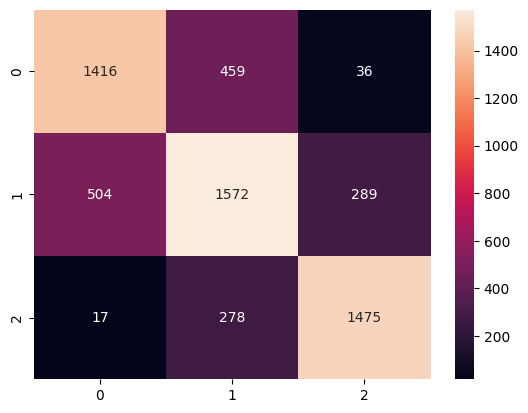

F1-score (weighted): 0.7377
Gini coefficient: 0.7847
ROC AUC: 0.8923
Balanced accuracy: 0.7463


In [ ]:
metrics = calculate_metrics(model, val_loader, device)

print(f"F1-score (weighted): {metrics['f1_weighted']:.4f}")
print(f"Gini coefficient: {metrics['gini']:.4f}")
print(f"ROC AUC: {metrics['roc_auc']:.4f}")
print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")

В сравнении с нашими базовыми моделями качество сильно улучшилось по всем метрикам.

# DenseNet-121 с теми же аугментациями

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
model = models.densenet121(weights='IMAGENET1K_V1')

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 3)

net = model.to(device)

optimizer = optim.Adam(net.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)
criterion = F.cross_entropy

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 139MB/s]


In [ ]:
train_loss_log, train_roc_auc_log, val_loss_log, val_roc_auc_log = train(
    net, optimizer, 12, train_loader, val_loader, device, scheduler, criterion
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/12
Train Loss: 0.6720 | Train ROC AUC: 0.8583
Val Loss: 0.8542 | Val ROC AUC: 0.8873



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 2/12
Train Loss: 0.6039 | Train ROC AUC: 0.8854
Val Loss: 0.8317 | Val ROC AUC: 0.9070



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

Epoch 10/12
Train Loss: 0.3889 | Train ROC AUC: 0.9529
Val Loss: 0.7367 | Val ROC AUC: 0.9584



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 11/12
Train Loss: 0.3844 | Train ROC AUC: 0.9541
Val Loss: 0.7350 | Val ROC AUC: 0.9593



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 12/12
Train Loss: 0.3884 | Train ROC AUC: 0.9530
Val Loss: 0.7355 | Val ROC AUC: 0.9586



Смотрим метрики

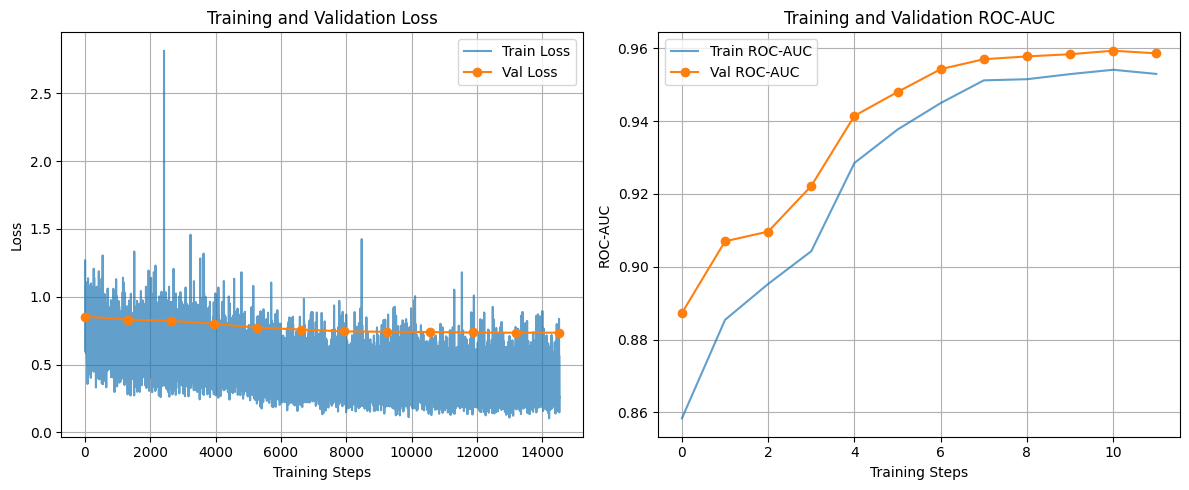

In [ ]:
plot_metrics(train_loss_log, train_roc_auc_log, val_loss_log, val_roc_auc_log)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


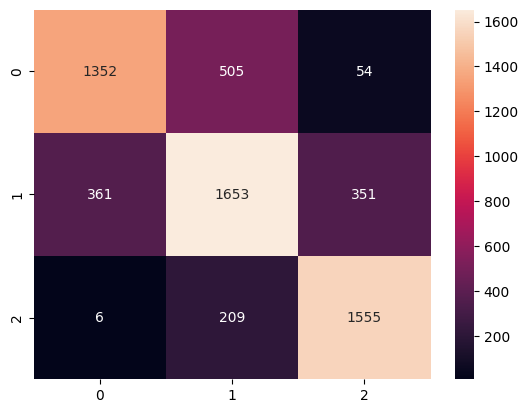

F1-score (weighted): 0.7528
Gini coefficient: 0.8139
ROC AUC: 0.9070
Balanced accuracy: 0.7617


In [ ]:
metrics = calculate_metrics(net, val_loader, device)

print(f"F1-score (weighted): {metrics['f1_weighted']:.4f}")
print(f"Gini coefficient: {metrics['gini']:.4f}")
print(f"ROC AUC: {metrics['roc_auc']:.4f}")
print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")

Сохраняем модель

In [ ]:
from google.colab import files
torch.save(model, 'full_model2.pth')
files.download('full_model2.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

densenet121 показала результат чуть лучше, чем реснет по всем метрикам.

# EfficientNet-B3 с FocalLoss и теми же аугментациями

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 3)

model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor=0.5, patience=2)
criterion = FocalLoss(alpha=0.5, gamma=2.0)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 187MB/s]


In [ ]:
train_loss_log, train_roc_auc_log, val_loss_log, val_roc_auc_log = train(
    model, optimizer, 12, train_loader, val_loader, device, scheduler, criterion
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/12
Train Loss: 0.1293 | Train ROC AUC: 0.8360
Val Loss: 0.1649 | Val ROC AUC: 0.8912



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 2/12
Train Loss: 0.1068 | Train ROC AUC: 0.8740
Val Loss: 0.1593 | Val ROC AUC: 0.9069



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

Epoch 10/12
Train Loss: 0.0474 | Train ROC AUC: 0.9609
Val Loss: 0.1136 | Val ROC AUC: 0.9847



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 11/12
Train Loss: 0.0439 | Train ROC AUC: 0.9665
Val Loss: 0.1111 | Val ROC AUC: 0.9869



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 12/12
Train Loss: 0.0420 | Train ROC AUC: 0.9692
Val Loss: 0.1087 | Val ROC AUC: 0.9898



Смотрим метрики

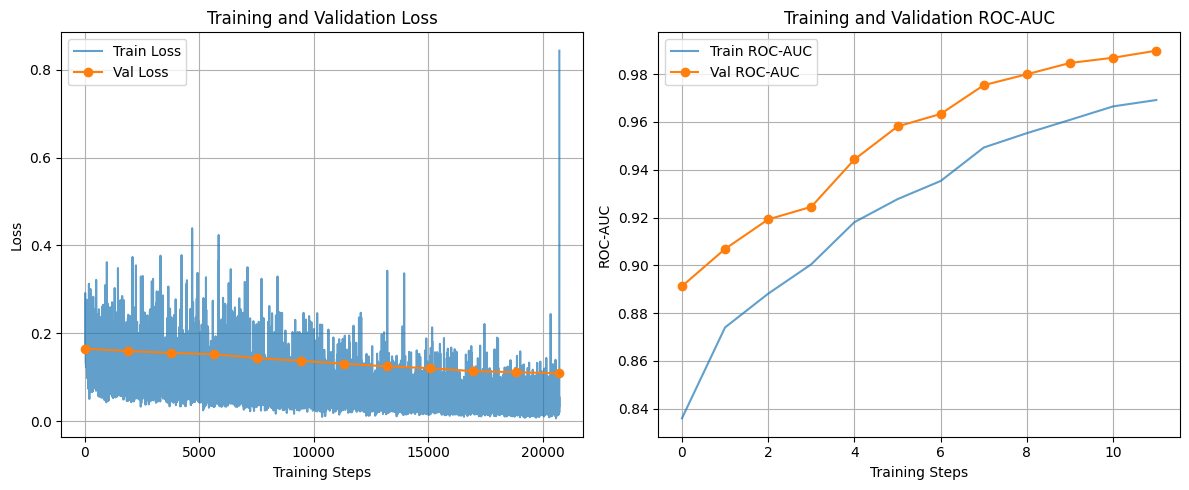

In [ ]:
plot_metrics(train_loss_log, train_roc_auc_log, val_loss_log, val_roc_auc_log)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


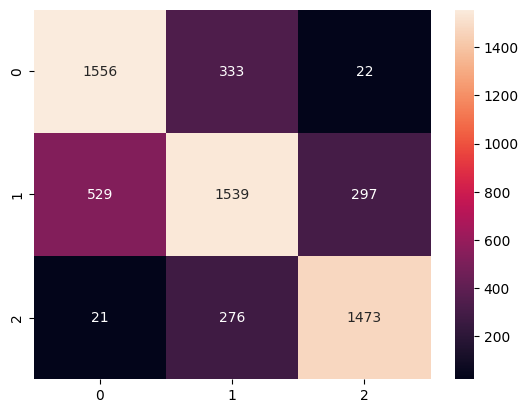

F1-score (weighted): 0.7538
Gini coefficient: 0.8094
ROC AUC: 0.9047
Balanced accuracy: 0.7657


In [ ]:
metrics = calculate_metrics(model, val_loader, device)

print(f"F1-score (weighted): {metrics['f1_weighted']:.4f}")
print(f"Gini coefficient: {metrics['gini']:.4f}")
print(f"ROC AUC: {metrics['roc_auc']:.4f}")
print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")

Сохраняем модель

In [ ]:
from google.colab import files
torch.save(model, 'full_model3.pth')
files.download('full_model3.pth')

torch.save(model.state_dict(), 'efficientnet_weights.pth')
files.download('efficientnet_weights.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

efficientnet по качеству и скорости обучения сравнима с densnet

# Ансамбль
## Используем стеккинг

In [ ]:
from torch.serialization import add_safe_globals

add_safe_globals([models.ResNet, models.DenseNet, models.EfficientNet])


resnet = torch.load('full_model.pth', weights_only=False)
densenet = torch.load('full_model2.pth', weights_only=False)
efficientnet = torch.load('full_model3.pth', weights_only=False)


models = [resnet.eval(), densenet.eval(), efficientnet.eval()]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_ = [model.to(device) for model in models]

In [ ]:
# Извлечение мета-признаков
X_train, y_train = prepare_meta_features(models, train_loader, device)
X_val, y_val = prepare_meta_features(models, val_loader, device)

# Обучение мета-модели
meta_model = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
meta_model.fit(X_train, y_train)

# Проверка качества
val_pred = meta_model.predict(X_val)
print(classification_report(y_val, val_pred, target_names=['Class 0', 'Class 1', 'Class 2']))

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


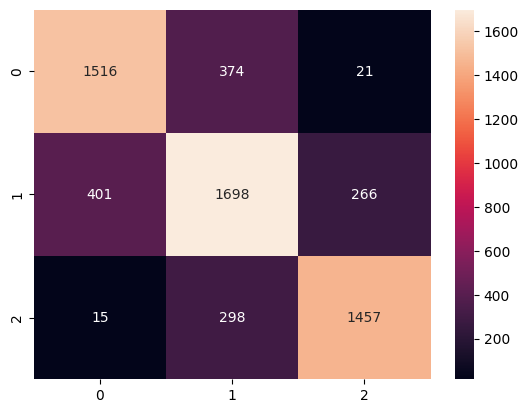


Метрики ансамбля:
1. ROC AUC: 0.9037
2. Коэффициент Джини: 0.8073
3. F1-score (weighted): 0.7727
4. Balanced Accuracy: 0.7781



In [23]:
metrics = calculate_metrics_meta(meta_model, X_val, y_val)

print(f"""
Метрики ансамбля:
1. ROC AUC: {metrics['ROC_AUC']:.4f}
2. Коэффициент Джини: {metrics['Gini']:.4f}
3. F1-score (weighted): {metrics['F1_weighted']:.4f}
4. Balanced Accuracy: {metrics['Balanced_accuracy']:.4f}
""")

Сохраним ансамбль

In [25]:
torch.save({
    'resnet': resnet.state_dict(),
    'densenet': densenet.state_dict(),
    'efficientnet': efficientnet.state_dict(),
}, 'base_models_weights.pth')

In [28]:
ensemble_metadata = {
    'meta_model': meta_model,  # Обученная LogisticRegression
    'class_names': ['Class 0', 'Class 1', 'Class 2'],
    'creation_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

}

joblib.dump(ensemble_metadata, 'stacking_ensemble_metadata.joblib')

['stacking_ensemble_metadata.joblib']

Стекинг чуть подтянул метрики F1-score и Balanced Accuracy, в сравнении с одиночными моделями.

В качестве итоговой модели выбираем ансамбль, так как его точность выше остальных моделей, а для нашей задачи это важно.